## Inversion del termino fuente

La inversion del termino fuente y la asimilacion de información corresponde a la inferencia de un termino $f(x)$ de la PDE, gracias a los valores observados de algun análisis anterior, denotados por $u_d^i$, para algunos puntos del dominio correspondiente, asi el objetivo es encontrar $f(x)$ y el campo completo $u(x)$ mediante los puntos dados.

In [37]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

np.random.seed(0)
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)

PyTorch 2.11.0+cpu | dispositivo: cpu


## 1. Arquitectura de las Redes Neuronales (PINN Multi-Red)

El diseño especifico de la PINN implica directamente a dos redes la primera corresponde a la aproximación de la solucion denotada por $\hat u (x;Θ)$

In [38]:
# 1. Red Neuronal corregida para aproximar el estado u(x)
class NetU(nn.Module):
    def __init__(self):
        super(NetU, self).__init__()
        # Cambiamos la primera capa lineal a entrada 1 (solo x) en lugar de 2 (x, t)
        self.net = nn.Sequential(
            nn.Linear(1, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        # Ahora recibe única y exclusivamente 'x'
        return self.net(x)

La segunda red corresponde a la aproximación de el termino $f(x)$, y esta red se denotara como $\hat f (x;\phi)$

In [39]:
# 2. Red Neuronal corregida para aproximar el término fuente desconocido f(x)
class NetF(nn.Module):
    def __init__(self):
        super(NetF, self).__init__()
        # Al igual que NetU, la entrada espacial es unidimensional (dim=1)
        self.net = nn.Sequential(
            nn.Linear(1, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        # Ahora recibe única y exclusivamente 'x'
        return self.net(x)

## 2. Clase residual de PINN y residuo de la física

la funcion dada por el ejercicio es:

$-∇^2u(x)=f(x)$,  $x \in Ω$, $u(x)=g(x)$, $x\in ∂Ω$

y su funcion de perdida debe de restringir ambas redes:

$\mathcal{l}(\theta,\phi)=\lambda _f\mathcal{l}_f(\theta,\phi) + \lambda _b\mathcal{l}_b(\theta) + \lambda _d \mathcal{l}_d(\theta)$

donde la perdida residual de la PDE se convierte en:

$\mathcal{l}_f(\theta,\phi)=\frac{1}{N_f} \sum_{i=1}^{N_f} |-\nabla^2\hat u(x_f^i;\theta)-\hat f(x_f^i;\phi)|^2$



In [40]:
class PoissonInversePINN():
    def __init__(self, x_data, u_data, x_bc, u_bc, x_collocation):

        # Datos internos observados (Asimilación de datos)
        self.x_data = torch.tensor(x_data, dtype=torch.float32, requires_grad=True)
        self.u_data = torch.tensor(u_data, dtype=torch.float32)

        # Condiciones de Frontera (Dirichlet u(x) = g(x))
        self.x_bc = torch.tensor(x_bc, dtype=torch.float32)
        self.u_bc = torch.tensor(u_bc, dtype=torch.float32)

        # Puntos de colocación en el dominio para la EDP
        self.x_f = torch.tensor(x_collocation, dtype=torch.float32, requires_grad=True)

        # Inicialización de las dos redes independientes (Ya no reciben tiempo 't')
        # Asegúrate de modificar NetU y NetF para que su capa lineal inicial tenga entrada de dimensión 1 en lugar de 2.
        self.net_u = NetU()  # Aproxima el campo de estado u(x)
        self.net_f = NetF()  # Aproxima la función fuente desconocida f(x)

        # Optimizador conjunto para entrenar los pesos de ambas redes neuronales
        self.optimizer = torch.optim.Adam(
            list(self.net_u.parameters()) + list(self.net_f.parameters()),
            lr=1e-3
        )

    def PDE_residual(self, x):
        """ Calcula el residuo de la ecuación de Poisson: u_xx + f(x) = 0 """
        u = self.net_u(x)

        # Primera derivada respecto a x
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

        # Segunda derivada respecto a x (Laplaciano en 1D)
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

        # Predicción de la red fuente desconocida f(x)
        f_pred = self.net_f(x)

        # Residuo formulado de la ecuación: -\nabla^2 u - f = 0  =>  -u_xx - f_pred = 0
        # O equivalentemente: u_xx + f_pred = 0
        residual = u_xx + f_pred
        return residual

    def train(self, epochs):
        for epoch in range(epochs):
            self.optimizer.zero_grad()

            # 1. Pérdida de Datos (Ajuste a mediciones ruidosas internas)
            u_pred_data = self.net_u(self.x_data)
            loss_data = torch.mean((self.u_data - u_pred_data) ** 2)

            # 2. Pérdida de Frontera (Cumplimiento de la condición Dirichlet u(x) = g(x))
            u_pred_bc = self.net_u(self.x_bc)
            loss_bc = torch.mean((self.u_bc - u_pred_bc) ** 2)

            # 3. Pérdida de la Física (Evaluación en los puntos de colocación)
            pde_res = self.PDE_residual(self.x_f)
            loss_pde = torch.mean(pde_res ** 2)

            # Pérdida total combinada
            loss = loss_data + loss_bc + loss_pde

            loss.backward()
            self.optimizer.step()

            if epoch % 500 == 0:
                print(f"Epoch {epoch:5d} | Loss Data: {loss_data.item():.4e} | Loss BC: {loss_bc.item():.4e} | Loss PDE: {loss_pde.item():.4e}")

## 3. Simulación de datos e inicialización.

Se generan datos sinteticos con algo de ruido para simular mediciones relaes, además se define el termino fuente real con el cual se contrastara el resultado de la PINN

In [41]:
# Configurar semilla para reproducibilidad
np.random.seed(42)

# Parámetros del dominio
L = 1.0  # Longitud del dominio espacial \Omega = [0, 1]

# Cantidad de puntos para el experimento
N_data = 100         # Mediciones internas escasas (asimilación de datos)
N_collocation = 500  # Puntos en el dominio para evaluar la física (EDP)

# 1. DEFINICIÓN DE FUNCIONES EXACTAS (Para generar el laboratorio sintético)
def u_exact_fn(x):
    """Solución exacta analítica elegida: u(x) = sin(pi * x)"""
    return np.sin(np.pi * x)

def f_exact_fn(x):
    """Fuente exacta que satisface -\nabla^2 u = f => f(x) = pi^2 * sin(pi * x)"""
    return (np.pi ** 2) * np.sin(np.pi * x)

# 2. GENERACIÓN DE DATOS DE ASIMILACIÓN (Puntos internos con ruido)
# Generamos puntos aleatorios estrictamente dentro del dominio abierto (0, L)
x_data = np.random.uniform(0.001, L - 0.001, (N_data, 1))
u_exact_values = u_exact_fn(x_data)

# Añadimos un 5% de ruido blanco gaussiano para simular el error de medición
noise_level = 0.05
noise = noise_level * np.std(u_exact_values) * np.random.randn(*u_exact_values.shape)
u_data = u_exact_values + noise

# 3. GENERACIÓN DE CONDICIONES DE FRONTERA (Dirichlet u(x) = g(x) en \partial\Omega)
# En 1D, las fronteras de [0, L] son los puntos exactos 0 y L
x_bc = np.array([[0.0], [L]])
u_bc = u_exact_fn(x_bc)  # Evaluamos u(0) y u(L), que para sin(pi*x) dará [[0.0], [0.0]]

# 4. GENERACIÓN DE PUNTOS DE COLOCACIÓN (Malla para evaluar la física)
x_collocation = np.random.uniform(0.0, L, (N_collocation, 1))

# 5. INICIALIZAR Y ENTRENAR EL MODELO PINN INVERSO
# Instanciamos la clase elíptica que definimos en el paso anterior
model = PoissonInversePINN(
    x_data=x_data,
    u_data=u_data,
    x_bc=x_bc,
    u_bc=u_bc,
    x_collocation=x_collocation
)

# Ejecutamos el ciclo de entrenamiento
model.train(epochs=3000)

Epoch     0 | Loss Data: 3.1491e-01 | Loss BC: 2.2244e-02 | Loss PDE: 1.1078e-03
Epoch   500 | Loss Data: 7.5263e-04 | Loss BC: 6.2669e-06 | Loss PDE: 6.1329e-05
Epoch  1000 | Loss Data: 6.6571e-04 | Loss BC: 4.3697e-05 | Loss PDE: 6.0660e-06
Epoch  1500 | Loss Data: 7.1810e-04 | Loss BC: 1.2159e-05 | Loss PDE: 5.4447e-06
Epoch  2000 | Loss Data: 6.6737e-04 | Loss BC: 4.1408e-05 | Loss PDE: 7.9145e-06
Epoch  2500 | Loss Data: 6.6415e-04 | Loss BC: 4.4197e-05 | Loss PDE: 4.8802e-06


## 4. Post-procesamiento y Validación del Perfil de la Fuente

Se crea una gráfica donde se visualiza la curva dada por el $f(x)$ real y el predicho por la red neuronal construida, para su comparación gráfica

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_345/3284830805.py:31: SyntaxWarning: invalid escape sequence '\p'
  ax[1].plot(x_test, f_real, 'r--', linewidth=2, label='Fuente Real $f(x) = \pi^2 \sin(\pi x)$')


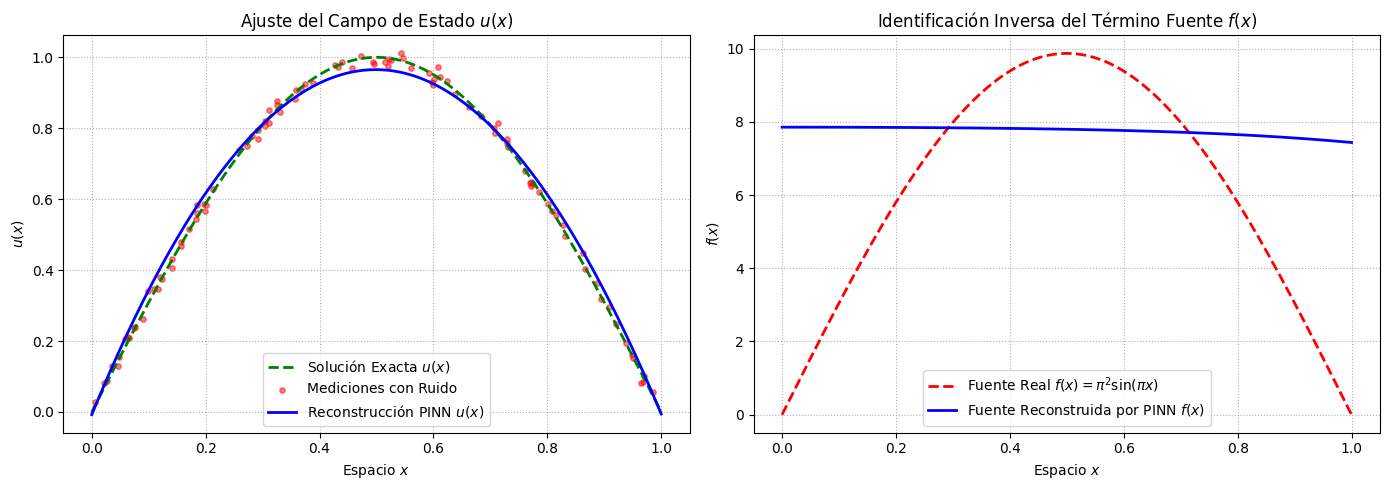

Error relativo L2 en la reconstrucción de u(x): 3.5039e-02
Error relativo L2 en el descubrimiento de f(x): 4.8418e-01


In [ ]:
# 1. Crear un rango ordenado y denso de puntos en x para evaluar la calidad del modelo
x_test = np.linspace(0, L, 200)[:, None]
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

# 2. Predicción del PINN (Desactivando gradientes para ahorrar memoria)
with torch.no_grad():
    # CORRECCIÓN: net_u y net_f ahora reciben únicamente 'x_test_tensor' (sin tiempo t)
    u_prediccion = model.net_u(x_test_tensor).numpy()
    f_prediccion = model.net_f(x_test_tensor).numpy()

# 3. Calcular los valores analíticos reales para comparar
u_real = u_exact_fn(x_test)
f_real = f_exact_fn(x_test)
        
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- PANEL IZQUIERDO: Reconstrucción del Campo de Estado u(x) ---
ax[0].plot(x_test, u_real, 'g--', linewidth=2, label='Solución Exacta $u(x)$')
ax[0].scatter(x_data, u_data, color='red', alpha=0.5, s=15, label='Mediciones con Ruido')
ax[0].plot(x_test, u_prediccion, 'b-', linewidth=2, label='Reconstrucción PINN ${u}(x)$')
ax[0].set_title('Ajuste del Campo de Estado $u(x)$')
ax[0].set_xlabel('Espacio $x$')
ax[0].set_ylabel('$u(x)$')
ax[0].legend()
ax[0].grid(True, linestyle=':')

# --- PANEL DERECHO: Inversión del Término Fuente f(x) ---
ax[1].plot(x_test, f_real, 'r--', linewidth=2, label='Fuente Real $f(x) = \pi^2 \sin(\pi x)$')
ax[1].plot(x_test, f_prediccion, 'b-', linewidth=2, label='Fuente Reconstruida por PINN ${f}(x)$')
ax[1].set_title('Identificación Inversa del Término Fuente $f(x)$')
ax[1].set_xlabel('Espacio $x$')
ax[1].set_ylabel('$f(x)$')
ax[1].legend()
ax[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

# 4. Cálculo de métricas de error globales (Norma L2 relativa)
error_u = np.linalg.norm(u_real - u_prediccion) / np.linalg.norm(u_real)
error_f = np.linalg.norm(f_real - f_prediccion) / np.linalg.norm(f_real)
print(f"Error relativo L2 en la reconstrucción de u(x): {error_u:.4e}")
print(f"Error relativo L2 en el descubrimiento de f(x): {error_f:.4e}")